In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss,balanced_accuracy_score,classification_report
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer,make_column_selector
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import os
import warnings
warnings.filterwarnings('ignore')
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [3]:
hr = pd.read_csv("HR_comma_sep.csv")
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [4]:
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore').set_output(transform='pandas')
transformer = ColumnTransformer([
    
    (
        "OHE",
        ohe,
        make_column_selector(dtype_include=object)
    ),
    
],remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")
ss = StandardScaler()

In [5]:
X,y = hr.drop('left',axis=1), hr['left']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=26,stratify=y)

In [9]:
n_estimators = [10, 25, 50, 75, 100]
rate = np.linspace(0.0001, 0.9, 30)
depth = [2, 3, 4, 5, 6]
scores = []

for n in tqdm(n_estimators):
    for r in rate:
        for d in depth:
            lgbm = LGBMClassifier(random_state=26, n_estimators=n, learning_rate=r, max_depth=d,verbose=-1)
            pipe = Pipeline(
        [
            (
                "OHE",
                transformer
            ),
            (
                "LGBM",
                lgbm
            )
        ])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            y_pred_prob = pipe.predict_proba(X_test)
            scores.append([n, r, d, log_loss(y_test, y_pred_prob), accuracy_score(y_test, y_pred)])
            
df_scores = pd.DataFrame(scores, columns = ["Number Of Estimators", "Learning Rate", "Depth", "Log Loss", "Accuracy Score"])
df_scores.sort_values(["Log Loss", "Accuracy Score"], ascending = [True, False])

100%|████████████████| 5/5 [00:48<00:00,  9.76s/it]


,Number Of Estimators,Learning Rate,Depth,Log Loss,Accuracy Score
644,100,0.248348,6,0.054756,0.987553
359,50,0.341441,6,0.055962,0.987331
494,75,0.248348,6,0.056076,0.986664
369,50,0.403503,6,0.056161,0.986886
639,100,0.217317,6,0.056745,0.987553
...,...,...,...,...,...
598,75,0.900000,5,2.986210,0.908869
748,100,0.900000,5,3.030951,0.913981
709,100,0.651752,6,3.120118,0.904868
749,100,0.900000,6,3.236638,0.910202


In [10]:
bm = LGBMClassifier(learning_rate=0.124224,max_depth=6,n_estimators=100,random_state=26)
pipe = Pipeline(
        [
            (
                "OHE",
                transformer
            ),
            (
                "GBM",
                bm
            )
        ])
pipe.fit(X,y)

Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fd3f95623d0>)],
                                   verbose_feature_names_out=False)),
                ('GBM',
                 LGBMClassifier(learning_rate=0.124224, max_depth=6,
                                random_state=26))])

In [11]:
bm.feature_importances_

array([ 15,  11,  13,   6,   4,  10,  33,  36,  42,  68,  37, 641, 478,
       444, 727, 331,  37,  12], dtype=int32)

In [12]:
X_transform = transformer.fit_transform(X)
X_transform.columns

Index(['Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical', 'salary_low', 'salary_medium',
       'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years'],
      dtype='object')

In [13]:
df = pd.DataFrame({"Feature" : X_transform.columns, "Importance" : bm.feature_importances_})
df = df.sort_values('Importance',ascending=False)

<Axes: xlabel='Importance', ylabel='Feature'>

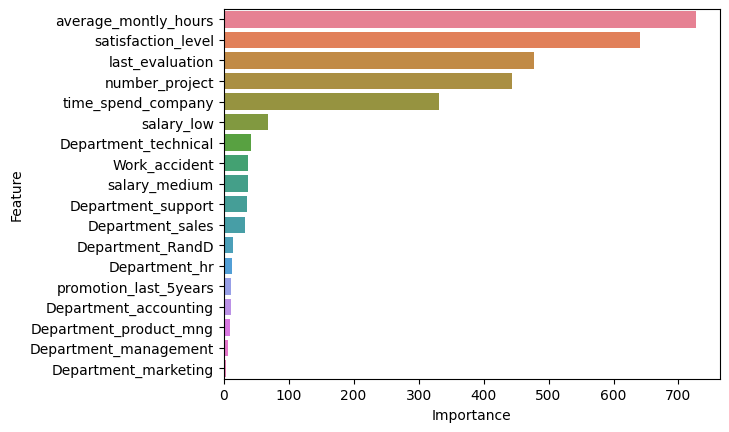

In [14]:
sns.barplot(data=df,x='Importance',y='Feature',hue='Feature')